In [1]:
"""
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

"""

'\n# This Python 3 environment comes with many helpful analytics libraries installed\n# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python\n# For example, here\'s several helpful packages to load\n\nimport numpy as np # linear algebra\nimport pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)\n\n# Input data files are available in the read-only "../input/" directory\n# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory\n\nimport os\nfor dirname, _, filenames in os.walk(\'/kaggle/input\'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n\n# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" \n# You can also write temporary files to /kaggle/temp/, but they won\'t be saved outside of the current session\n\n# Use the kagglehub client library to attac

In [2]:
import pandas as pd
import numpy as np


In [3]:
df=pd.read_csv("./Churn_Modelling.csv")

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.shape

(10000, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [9]:
df["Geography"].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [10]:
df["Gender"].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [11]:
df.drop(["RowNumber","CustomerId","Surname"],axis="columns",inplace=True)

In [12]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited'],
      dtype='object')

In [13]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
df=pd.get_dummies(df,columns=["Geography","Gender"],drop_first=True)

In [15]:
df.columns

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_Germany',
       'Geography_Spain', 'Gender_Male'],
      dtype='object')

In [16]:
X=df.drop(columns=["Exited"])
y=df["Exited"]

In [17]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [18]:
X.shape

(10000, 11)

In [19]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64

In [20]:
y.shape

(10000,)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        10000 non-null  int64  
 1   Age                10000 non-null  int64  
 2   Tenure             10000 non-null  int64  
 3   Balance            10000 non-null  float64
 4   NumOfProducts      10000 non-null  int64  
 5   HasCrCard          10000 non-null  int64  
 6   IsActiveMember     10000 non-null  int64  
 7   EstimatedSalary    10000 non-null  float64
 8   Exited             10000 non-null  int64  
 9   Geography_Germany  10000 non-null  bool   
 10  Geography_Spain    10000 non-null  bool   
 11  Gender_Male        10000 non-null  bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 732.5 KB


In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [23]:
X_train.shape

(8000, 11)

In [24]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


In [25]:
X_train_scaled

array([[-0.23082038, -0.94449979, -0.70174202, ...,  1.71490137,
        -0.57273139,  0.91509065],
       [-0.25150912, -0.94449979, -0.35520275, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [-0.3963303 ,  0.77498705,  0.33787579, ...,  1.71490137,
        -0.57273139, -1.09278791],
       ...,
       [ 0.22433188,  0.58393295,  1.3774936 , ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 0.13123255,  0.01077067,  1.03095433, ..., -0.58312392,
        -0.57273139, -1.09278791],
       [ 1.1656695 ,  0.29735181,  0.33787579, ...,  1.71490137,
        -0.57273139,  0.91509065]], shape=(8000, 11))

In [26]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [27]:
model=Sequential()

model.add(Dense(3,activation="relu",input_dim=11))
model.add(Dense(11,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

/Users/kristalshrestha/Documents/Code/DeepLearning_practice/venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 11)             │            44 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92 (368.00 B)

 Trainable params: 92 (368.00 B)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(loss="binary_crossentropy",optimizer="Adam",metrics=["accuracy"])

In [30]:
history=model.fit(X_train_scaled,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7633 - loss: 0.5571 - val_accuracy: 0.7975 - val_loss: 0.5042
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step - accuracy: 0.7972 - loss: 0.4859 - val_accuracy: 0.7975 - val_loss: 0.4747
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - accuracy: 0.7972 - loss: 0.4625 - val_accuracy: 0.7981 - val_loss: 0.4550
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.8017 - loss: 0.4445 - val_accuracy: 0.8031 - val_loss: 0.4384
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.8106 - loss: 0.4309 - val_accuracy: 0.8112 - val_loss: 0.4253
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - accuracy: 0.8188 - loss: 0.4223 - val_accuracy: 0.8150 - val_loss: 0.4178
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step - accuracy: 0.8203 - loss: 0.4171 - val_accuracy: 0.8188 - val_loss: 0.4131
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 614us/step - accuracy: 0.8216 - loss: 0.4

In [31]:
history.history

{'accuracy': [0.7632812261581421,
  0.7971875071525574,
  0.7971875071525574,
  0.8017187714576721,
  0.8106250166893005,
  0.8187500238418579,
  0.8203125,
  0.8215625286102295,
  0.8231250047683716,
  0.8228124976158142,
  0.8229687213897705,
  0.8240625262260437,
  0.8257812261581421,
  0.8251562714576721,
  0.8256250023841858,
  0.8262500166893005,
  0.8267187476158142,
  0.8262500166893005,
  0.8282812237739563,
  0.8271874785423279,
  0.8265625238418579,
  0.8282812237739563,
  0.8274999856948853,
  0.8298437595367432,
  0.8290625214576721,
  0.8278124928474426,
  0.8284375071525574,
  0.8290625214576721,
  0.8287500143051147,
  0.8276562690734863,
  0.828906238079071,
  0.8284375071525574,
  0.8290625214576721,
  0.8287500143051147,
  0.8276562690734863,
  0.8292187452316284,
  0.8298437595367432,
  0.8310937285423279,
  0.8306249976158142,
  0.831250011920929,
  0.8315625190734863,
  0.8467187285423279,
  0.850781261920929,
  0.8515625,
  0.8532812595367432,
  0.853906273841857

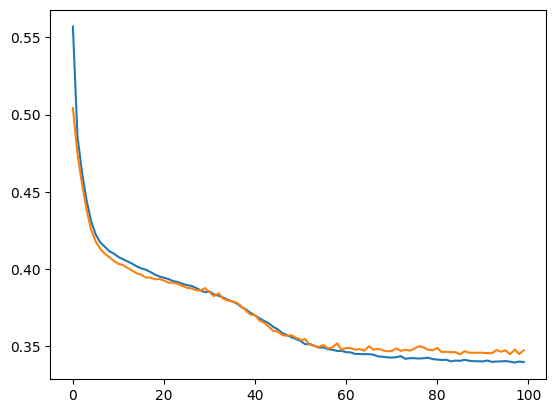

In [32]:
import matplotlib.pyplot as plt
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

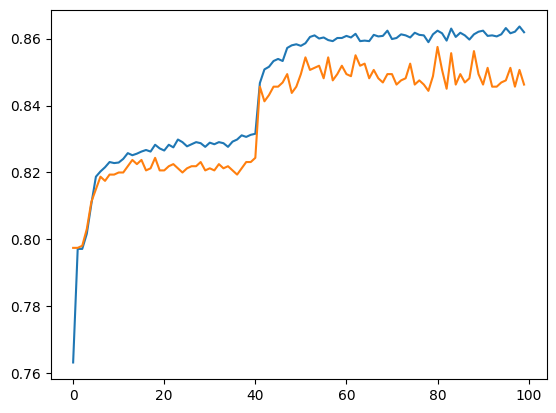

In [33]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

In [34]:
model.layers[0].get_weights()

[array([[-0.01079298, -0.03328486,  0.04964599],
        [-0.28807035,  0.08681814, -0.9808149 ],
        [-0.04836209,  0.05058755, -0.08246614],
        [-0.27855712, -0.28142875, -0.01226275],
        [-1.6310226 , -0.6479274 , -0.48579443],
        [-0.06915825,  0.03162203, -0.06700515],
        [-0.20551538,  0.35012388, -0.33984077],
        [ 0.00963177,  0.01475475,  0.00252604],
        [ 0.14912616,  0.04315849, -0.01788437],
        [-0.04708242, -0.02410953, -0.06332771],
        [ 0.03352523,  0.14830887,  0.0271358 ]], dtype=float32),
 array([0.17872095, 1.5207288 , 1.3537798 ], dtype=float32)]

In [35]:
y_log=model.predict(X_test_scaled)
y_log

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step


array([[0.04417126],
       [0.12369598],
       [0.0390785 ],
       ...,
       [0.00522416],
       [0.02687161],
       [0.38059667]], shape=(2000, 1), dtype=float32)

In [36]:
y_pred=np.where(y_log > 0.5,1,0)
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [37]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8585